# RANDOM FOREST

Son muchos los modelos de regresión capaces de predecir una variable respuesta Y en función de uno o varios predictores X. Algunos de ellos consideran que la relación entre Y y X es únicamente lineal (regresión lineal, GLM), mientras que otros permiten incorporar relaciones no lineales o incluso interacciones entre los predictores (SVM, Random Forest, Boosting). De una forma u otra, todos ellos tratan de inferir la relación entre X e Y.

> *OYE HEMOS ESTADO SOLO HACIENDO REGRESIÓN LINEAL? SEGÚN https://rpubs.com/Joaquin_AR/587903 PARA NADA LO MÁS ADECUADO NO?*
> Vale al parecer una RNN no es regresión lineal por q tiene una capa oculta (memoria) así q es deep like that jejjej

# rf01 — Random Forest para predicción de delta de tela

## Por qué Random Forest como alternativa a la RNN

La RNN aprende bien patrones temporales pero tiene dos problemas para este caso:
- Necesita muchos datos y epochs para converger
- Es sensible a la inestabilidad acumulativa en inferencia

El Random Forest no tiene memoria temporal explícita, pero si le damos
**varios frames de historia concatenados como features planas**, puede capturar
el mismo contexto temporal de forma mucho más simple y sin riesgo de explotar.

## Estructura del input

Para imitar la ventana temporal de `rnn02` (seq_len=5):
```
X = [frame_t-4 | frame_t-3 | frame_t-2 | frame_t-1 | frame_t]  (aplanado)
  = 5 frames × 6 vértices × 4 features = 120 features por muestra

y = delta_t+1 = pos_t+1 - pos_t
  = 6 vértices × 3 coords = 18 valores
  → un árbol por coordenada (18 RandomForests en total) usando MultiOutputRegressor
```

---
## 1. Carga de datos

In [3]:
import pandas as pd
import numpy as np

csv_path     = 'data/clothDataset_47_.csv'
df           = pd.read_csv(csv_path)
df.columns   = df.columns.str.strip()

NUM_VERTICES = 25
NUM_FEATURES = 13   # x, y, z, sdf
SEQ_LEN      = 5   # frames de historia (misma ventana que rnn02)

# Construir tensor [Frames, Vertices, 4]
selected_cols = []
for i in range(NUM_VERTICES):
    selected_cols.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

#data = df[selected_cols].values.astype('float32')          # [Frames, V*F]
# VAMOS CON TODAS
df = df.drop(columns=['frame'])
data = df.values.astype('float32') 
data = data.reshape(len(data), NUM_VERTICES, NUM_FEATURES) # [Frames, V, F]

print(f"Frames totales: {len(data)}")
print(f"Shape: {data.shape}  # [Frames, Vertices, Features]")

Frames totales: 5000
Shape: (5000, 25, 13)  # [Frames, Vertices, Features]


---
## 2. Construcción de X e y

Cada muestra = ventana de `SEQ_LEN` frames aplanada → vector de 120 features.  
Target = delta de posición del frame siguiente (18 valores).

In [4]:
X_list = []
y_list = []

for i in range(SEQ_LEN, len(data) - 1):
    # Historia: SEQ_LEN frames aplanados
    window = data[i - SEQ_LEN : i]          # [seq_len, V, F]
    X_list.append(window.flatten())         # [seq_len * V * F]

    # Target: delta de posición (solo x,y,z, no sdf)
    pos_t  = data[i,   :, 0:3]             # [V, 3]
    pos_t1 = data[i+1, :, 0:3]             # [V, 3]
    delta  = pos_t1 - pos_t                 # [V, 3]
    y_list.append(delta.flatten())          # [V * 3]

X = np.stack(X_list)  # [N, seq_len*V*F]
y = np.stack(y_list)  # [N, V*3]

print(f"X shape: {X.shape}   # {SEQ_LEN} frames × {NUM_VERTICES} verts × {NUM_FEATURES} feats")
print(f"y shape: {y.shape}   # {NUM_VERTICES} verts × 3 coords")

X shape: (4994, 1625)   # 5 frames × 25 verts × 13 feats
y shape: (4994, 75)   # 25 verts × 3 coords


---
## 3. Split cronológico y normalización

In [6]:
from sklearn.preprocessing import StandardScaler

""" 
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
"""
X_train, X_test = X, X
y_train, y_test = y, y

# Normalizar X (el RF no lo necesita, pero ayuda si luego comparas con RNN)
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Normalizar y
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

Train: 4994 muestras | Test: 4994 muestras


---
## 4. Entrenamiento del Random Forest

`MultiOutputRegressor` entrena un árbol independiente por cada una de las 18 salidas.  
Es lo más directo; si quieres un único bosque compartido puedes usar `RandomForestRegressor`
directamente (soporta multi-output de forma nativa pero comparte árboles entre salidas).

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import time

""" 
El Random Forest es un algoritmo de sklearn, no una red neuronal. No tiene gradientes ni backprop, así que PyTorch no aporta nada — internamente son árboles de decisión, no operaciones tensoriales.
"""

# RandomForestRegressor soporta multi-output nativamente
# (un único bosque predice todos los outputs a la vez)
rf = RandomForestRegressor(
    n_estimators=200,     # número de árboles
    max_depth=None,       # árboles profundos por defecto
    min_samples_leaf=2,   # evita overfitting en hojas
    max_features='sqrt',  # subset de features por split (estándar en RF)
    n_jobs=-1,            # usar todos los cores
    random_state=42
)

t0 = time.time()
rf.fit(X_train_sc, y_train_sc)
print(f"Entrenamiento: {time.time() - t0:.1f}s")
print(f"Árboles entrenados: {rf.n_estimators}")

Entrenamiento: 12.1s
Árboles entrenados: 200


---
## 5. Evaluación

R²  (global):          0.9755
MAE (global):          0.000235
Avg vertex error:      0.000501
Error relativo medio:  0.2%
Error relativo máximo: 0.5%  (vértice 4)
Error relativo mínimo: 0.0%  (vértice 7)


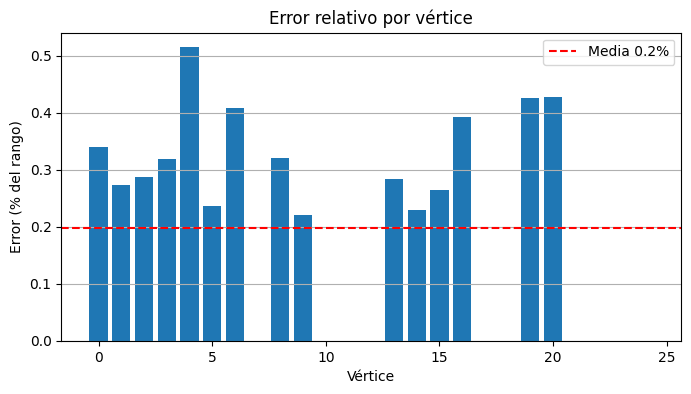

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

y_pred_sc = rf.predict(X_test_sc)

# Desnormalizar para métricas en unidades reales
y_pred = scaler_y.inverse_transform(y_pred_sc)  # [N, V*3]

# ── Vertex error (igual que en rnn02) ────────────────────────────
y_pred_3d = y_pred.reshape(-1, NUM_VERTICES, 3)   # [N, V, 3]
y_test_3d = y_test.reshape(-1, NUM_VERTICES, 3)   # [N, V, 3]

vertex_errors = np.linalg.norm(y_pred_3d - y_test_3d, axis=-1)  # [N, V]
avg_vertex_err = vertex_errors.mean()

# ── Error relativo al rango de movimiento ─────────────────────────
pos_data = data[:, :, 0:3]                        # [Frames, V, 3]
vertex_range = (pos_data.max(axis=0) - pos_data.min(axis=0)).mean(axis=-1)  # [V]
error_per_vertex = vertex_errors.mean(axis=0)     # [V]
relative_error   = error_per_vertex / (vertex_range+0.0000000001)

print(f"R²  (global):          {r2_score(y_test, y_pred):.4f}")
print(f"MAE (global):          {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Avg vertex error:      {avg_vertex_err:.6f}")
print(f"Error relativo medio:  {relative_error.mean():.1%}")
print(f"Error relativo máximo: {relative_error.max():.1%}  (vértice {relative_error.argmax()})")
print(f"Error relativo mínimo: {relative_error.min():.1%}  (vértice {relative_error.argmin()})")

# ── Error relativo por vértice ────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.bar(range(NUM_VERTICES), relative_error * 100)
plt.axhline(relative_error.mean() * 100, color='red',
            linestyle='--', label=f'Media {relative_error.mean():.1%}')
plt.title('Error relativo por vértice')
plt.xlabel('Vértice'); plt.ylabel('Error (% del rango)')
plt.legend(); plt.grid(True, axis='y')
plt.show()

---
## 6. Rollout autoregresivo

Igual que en `rnn02`: predecimos N pasos en cadena, usando cada predicción
como input del siguiente paso.

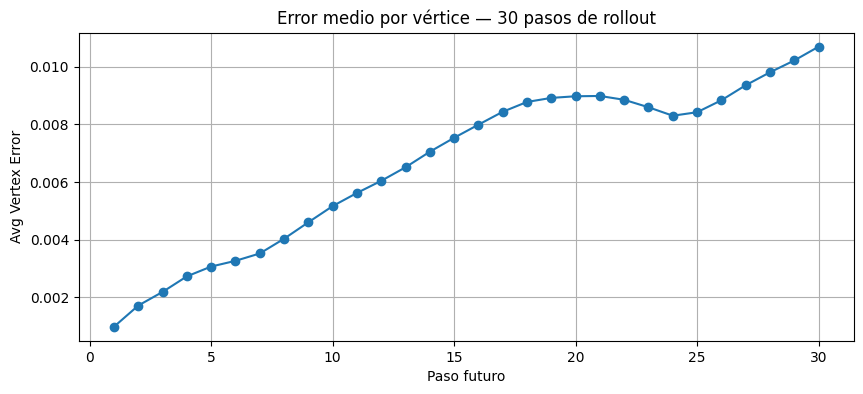

In [9]:
N_STEPS   = 30
start_idx = int(0.8 * len(data))  # primer frame del test set

rollout_preds = []
rollout_reals = []

# Ventana inicial: SEQ_LEN frames reales
window = data[start_idx - SEQ_LEN : start_idx].copy()  # [seq_len, V, F]

for step in range(N_STEPS):
    x_input = window.flatten().reshape(1, -1)           # [1, seq_len*V*F]
    x_input_sc = scaler_X.transform(x_input)

    pred_delta_sc = rf.predict(x_input_sc)              # [1, V*3]
    pred_delta    = scaler_y.inverse_transform(pred_delta_sc)
    pred_delta_3d = pred_delta.reshape(NUM_VERTICES, 3) # [V, 3]

    last_pos  = window[-1, :, 0:3]                      # [V, 3]
    pred_pos  = last_pos + pred_delta_3d                # [V, 3]

    rollout_preds.append(pred_pos.copy())
    real_pos = data[start_idx + step, :, 0:3]
    rollout_reals.append(real_pos.copy())

    # Feedback: insertar predicción en la ventana
    new_frame        = window[-1].copy()                # [V, F]
    new_frame[:, 0:3] = pred_pos
    # sdf: usamos el real del siguiente frame (colisión externa)
    new_frame[:, 3]   = data[start_idx + step, :, 3]
    window = np.concatenate([window[1:], new_frame[np.newaxis]], axis=0)

rollout_errors = [
    np.linalg.norm(rollout_preds[i] - rollout_reals[i], axis=-1).mean()
    for i in range(N_STEPS)
]

plt.figure(figsize=(10, 4))
plt.plot(range(1, N_STEPS+1), rollout_errors, marker='o')
plt.title(f'Error medio por vértice — {N_STEPS} pasos de rollout')
plt.xlabel('Paso futuro'); plt.ylabel('Avg Vertex Error')
plt.grid(True)
plt.show()

---
## 7. Visualización 3D

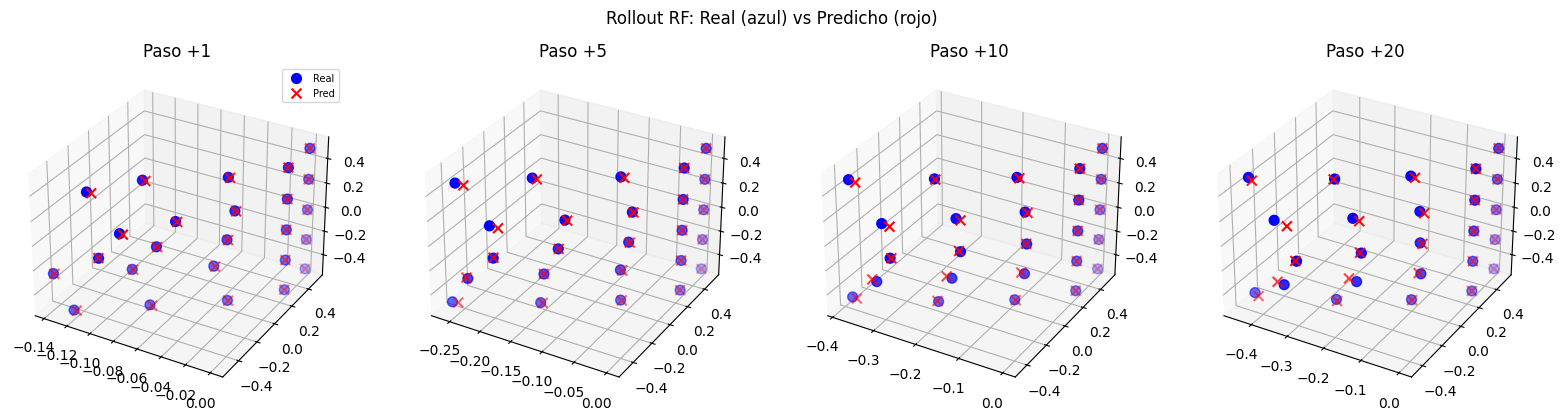

In [10]:
steps_to_show = [0, 4, 9, 19]
fig = plt.figure(figsize=(16, 4))

for col, step in enumerate(steps_to_show):
    ax = fig.add_subplot(1, len(steps_to_show), col+1, projection='3d')
    real = rollout_reals[step]
    pred = rollout_preds[step]

    ax.scatter(real[:, 0], real[:, 1], real[:, 2], c='blue', s=50, label='Real',  marker='o')
    ax.scatter(pred[:, 0], pred[:, 1], pred[:, 2], c='red',  s=50, label='Pred',  marker='x')
    for i in range(NUM_VERTICES):
        ax.plot([real[i,0], pred[i,0]], [real[i,1], pred[i,1]],
                [real[i,2], pred[i,2]], 'gray', linestyle='dotted', linewidth=0.5)
    ax.set_title(f'Paso +{step+1}')
    if col == 0: ax.legend(fontsize=7)

plt.suptitle('Rollout RF: Real (azul) vs Predicho (rojo)', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Feature importance

Qué frames de la ventana temporal importan más para la predicción.

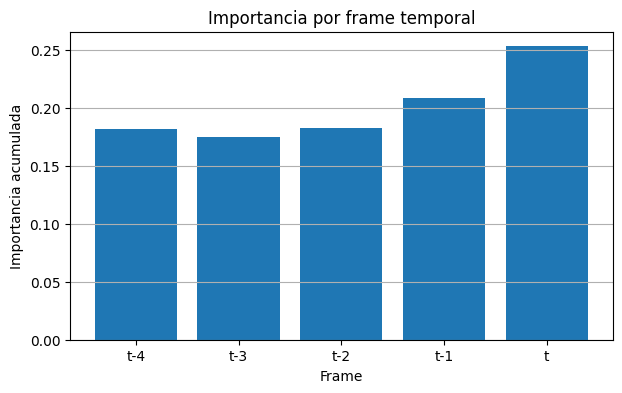

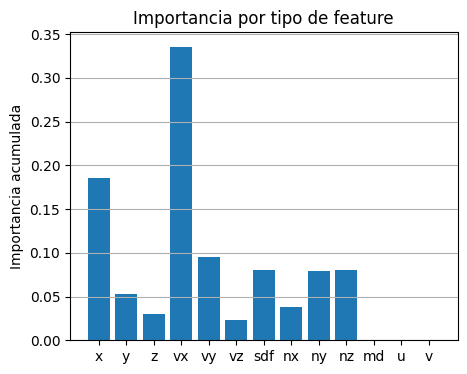

In [11]:
importances = rf.feature_importances_  # [seq_len * V * F]

# Agrupar por frame temporal
n_feats_per_frame = NUM_VERTICES * NUM_FEATURES
importance_by_frame = importances.reshape(SEQ_LEN, n_feats_per_frame).sum(axis=1)

plt.figure(figsize=(7, 4))
labels = [f't-{SEQ_LEN - i - 1}' if i < SEQ_LEN - 1 else 't' for i in range(SEQ_LEN)]
plt.bar(labels, importance_by_frame)
plt.title('Importancia por frame temporal')
plt.xlabel('Frame'); plt.ylabel('Importancia acumulada')
plt.grid(True, axis='y')
plt.show()

# Agrupar por feature (x, y, z, sdf) sumando sobre frames y vértices
importance_by_feat = importances.reshape(SEQ_LEN, NUM_VERTICES, NUM_FEATURES).sum(axis=(0, 1))
plt.figure(figsize=(5, 4))
plt.bar(['x', 'y', 'z', 'vx', 'vy', 'vz', 'sdf', 'nx', 'ny', 'nz', 'md', 'u', 'v'], importance_by_feat)
plt.title('Importancia por tipo de feature')
plt.ylabel('Importancia acumulada')
plt.grid(True, axis='y')
plt.show()

---
## 9. Tuning rápido con RandomizedSearchCV

Si los resultados no son buenos, ejecuta esta celda para buscar mejores hiperparámetros.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from tqdm import tqdm
import time

# ── Wrapper to track progress ──────────────────────────────────────────
class TqdmRandomizedSearchCV(RandomizedSearchCV):
    def fit(self, X, y=None, **fit_params):
        n_fits = self.n_iter * self.cv
        print(f"🔍 Iniciando búsqueda: {self.n_iter} combinaciones × {self.cv} folds = {n_fits} fits\n")
        start = time.time()
        result = super().fit(X, y, **fit_params)
        elapsed = time.time() - start
        print(f"\n✅ Búsqueda completada en {elapsed:.1f}s")
        return result

param_dist = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [2, 4],
    'max_features':     ['sqrt', 0.5],
}

search = TqdmRandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='neg_mean_absolute_error',
    n_jobs=1,          # ← must be 1 for live progress to print in order
    random_state=42,
    verbose=3          # ← prints each fit: [CV 1/2] fold score + time
)

search.fit(X_train_sc, y_train_sc)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor MAE (CV):     {-search.best_score_:.6f}")

best_rf = search.best_estimator_
y_pred_best = scaler_y.inverse_transform(
    best_rf.predict(X_test_sc).reshape(-1, 1)   # explicit reshape is safer
)
print(f"Vertex error (mejor RF): {np.linalg.norm((y_pred_best - y_test).reshape(-1, NUM_VERTICES, 3), axis=-1).mean():.6f}")

🔍 Iniciando búsqueda: 10 combinaciones × 2 folds = 20 fits

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV 1/2] END max_depth=None, max_features=0.5, min_samples_leaf=4, n_estimators=200;, score=-0.167 total time=  56.5s
[CV 2/2] END max_depth=None, max_features=0.5, min_samples_leaf=4, n_estimators=200;, score=-0.159 total time= 1.1min
[CV 1/2] END max_depth=20, max_features=sqrt, min_samples_leaf=2, n_estimators=100;, score=-0.168 total time=   2.1s
[CV 2/2] END max_depth=20, max_features=sqrt, min_samples_leaf=2, n_estimators=100;, score=-0.152 total time=   2.2s
[CV 1/2] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=200;, score=-0.167 total time=   4.1s
[CV 2/2] END max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=200;, score=-0.151 total time=   6.1s
[CV 1/2] END max_depth=None, max_features=0.5, min_samples_leaf=2, n_estimators=50;, score=-0.161 total time=  21.3s
[CV 2/2] END max_depth=None, max_features=0.5, min_sam

ValueError: non-broadcastable output operand with shape (74925,1) doesn't match the broadcast shape (74925,75)

In [9]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':    [100, 200, 400],
    'max_depth':       [10, 20, 30, None],
    'min_samples_leaf':[1, 2, 4],
    'max_features':    ['sqrt', 'log2', 0.5],
}

search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train_sc, y_train_sc)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor MAE (CV):     {-search.best_score_:.6f}")

# Reevaluar con el mejor modelo
best_rf = search.best_estimator_
y_pred_best = scaler_y.inverse_transform(best_rf.predict(X_test_sc))
print(f"Vertex error (mejor RF): {np.linalg.norm((y_pred_best - y_test).reshape(-1, NUM_VERTICES, 3), axis=-1).mean():.6f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

---
## 10. Guardar modelo

In [ ]:
import joblib

joblib.dump(rf,        'rf_cloth_delta.joblib')
joblib.dump(scaler_X,  'rf_scaler_X.joblib')
joblib.dump(scaler_y,  'rf_scaler_y.joblib')
print("Modelo y scalers guardados.")

# Para cargar:
# rf       = joblib.load('rf_cloth_delta.joblib')
# scaler_X = joblib.load('rf_scaler_X.joblib')
# scaler_y = joblib.load('rf_scaler_y.joblib')



Modelo y scalers guardados.


In [15]:
import numpy as np
import onnx
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# ── Parámetros (deben coincidir con rf01_delta.ipynb) ────────────
INPUT_DIM    = SEQ_LEN * NUM_VERTICES * NUM_FEATURES
OUTPUT_DIM   = NUM_VERTICES * 3                

# ── Convertir a ONNX ─────────────────────────────────────────────
# El RF espera [N, 120] y devuelve [N, 18]
initial_type = [('input', FloatTensorType([None, INPUT_DIM]))]

onnx_model = convert_sklearn(
    rf,                          # modelo entrenado en rf01_delta.ipynb
    initial_types=initial_type,
    target_opset=15
)

# ── Verificar ────────────────────────────────────────────────────
onnx.checker.check_model(onnx_model)

# ── Guardar ──────────────────────────────────────────────────────
ONNX_PATH = 'rf_cloth_delta.onnx'
with open(ONNX_PATH, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f'Modelo guardado en {ONNX_PATH}')
print(f'Input shape esperado en Unity: [1, {INPUT_DIM}]  (vector plano)')
print(f'Output shape:                  [1, {OUTPUT_DIM}]')

print(rf.n_outputs_)          # should be 18, if 1 → problem is in training
print(rf.n_estimators)
print(y_train_sc.shape)       # what shape was y when you called .fit()?

Modelo guardado en rf_cloth_delta.onnx
Input shape esperado en Unity: [1, 1625]  (vector plano)
Output shape:                  [1, 75]
75
200
(4994, 75)


In [14]:
# ── Test de inferencia con ONNXRuntime ───────────────────────────
session = ort.InferenceSession(ONNX_PATH)

# Input de prueba: una ventana aleatoria normalizada
dummy = X_test_sc[:1].astype(np.float32)  # [1, 120]
ort_out = session.run(None, {'input': dummy})

print(f'Output shape ONNXRuntime: {ort_out[0].shape}')  # debe ser [1, 18]

# Comparar con sklearn para confirmar que la conversión es correcta
sklearn_out = rf.predict(dummy)
max_diff = np.abs(ort_out[0] - sklearn_out).max()
print(f'Diferencia máxima sklearn vs ONNX: {max_diff:.2e}  (debe ser < 1e-4)')

# Desnormalizar y mostrar el delta predicho
delta_pred = scaler_y.inverse_transform(ort_out[0]).reshape(NUM_VERTICES, 3)
print(f'\nDelta predicho por vértice (primeros 3):')
for i in range(3):
    print(f'  v{i}: dx={delta_pred[i,0]:.5f}  dy={delta_pred[i,1]:.5f}  dz={delta_pred[i,2]:.5f}')

Output shape ONNXRuntime: (1, 75)
Diferencia máxima sklearn vs ONNX: 1.46e-07  (debe ser < 1e-4)

Delta predicho por vértice (primeros 3):
  v0: dx=-0.02042  dy=0.00345  dz=-0.00065
  v1: dx=-0.02460  dy=0.00315  dz=0.00007
  v2: dx=-0.03270  dy=0.00528  dz=-0.00088


In [16]:
# ── Guardar parámetros de normalización para Unity ───────────────
# El .cs los carga desde un JSON igual que antes
import json

# Los scalers de sklearn guardan mean_ y scale_ por feature
# input: [120] features (5 frames × 6 vértices × 4 features)
# target: [18] features (6 vértices × 3 coords)
#
# En Unity solo necesitamos normalizar por tipo de feature (x,y,z,sdf)
# así que extraemos los valores del primer bloque (son iguales para todos los frames)
norm_data = {
    'mean':        scaler_X.mean_[:NUM_FEATURES].tolist(),   # [x_mean, y_mean, z_mean, sdf_mean]
    'std':         scaler_X.scale_[:NUM_FEATURES].tolist(),  # [x_std,  y_std,  z_std,  sdf_std]
    'target_mean': scaler_y.mean_[:3].tolist(),              # [dx_mean, dy_mean, dz_mean]
    'target_std':  scaler_y.scale_[:3].tolist()              # [dx_std,  dy_std,  dz_std]
}

with open('rf_cloth_norm_params.json', 'w') as f:
    json.dump(norm_data, f, indent=2)

print('rf_cloth_norm_params_rf.json guardado.')
print(json.dumps(norm_data, indent=2))

rf_cloth_norm_params_rf.json guardado.
{
  "mean": [
    -0.0015858987973755227,
    -0.2158076547483086,
    0.4930245877983191,
    -0.001300332600777164,
    0.00017601765133108422,
    -2.06265870822389e-05,
    0.737268345740064,
    -0.05253552740551864,
    0.09695019013209967,
    0.6132484945264587,
    1.0,
    0.75,
    0.0
  ],
  "std": [
    0.17763542151611098,
    0.028778195803412673,
    0.0077745052113432096,
    0.7054684825082859,
    0.20781145169231066,
    0.06379161344337568,
    0.45163225711478583,
    0.7426378303866014,
    0.04680763720563099,
    0.24096692987291363,
    1.0,
    1.0,
    1.0
  ],
  "target_mean": [
    -3.1889387284650555e-07,
    -6.537832257076412e-08,
    -7.068831585481924e-07
  ],
  "target_std": [
    0.014128868705956027,
    0.004157875130464013,
    0.0012759854733390562
  ]
}


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx
import onnxruntime as ort

# ── 1. Train MLP ──────────────────────────────────────────────────
mlp = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128),  # desktop → can go bigger if needed
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,        # stops when val loss plateaus
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=True                # prints loss each 100 iters
)

mlp.fit(X_train_sc, y_train_sc)
print(f"Iterations: {mlp.n_iter_}")

# ── 2. Compare RF vs MLP accuracy ────────────────────────────────
def vertex_error(model, X, y_true):
    y_pred = scaler_y.inverse_transform(model.predict(X))
    return np.linalg.norm(
        (y_pred - y_true).reshape(-1, NUM_VERTICES, 3), axis=-1
    ).mean()

print(f"Vertex error RF:  {vertex_error(rf,  X_test_sc, y_test):.6f}")
print(f"Vertex error MLP: {vertex_error(mlp, X_test_sc, y_test):.6f}")

# ── 3. Export to ONNX ─────────────────────────────────────────────
initial_type = [('input', FloatTensorType([None, INPUT_DIM]))]

onnx_model = convert_sklearn(
    mlp,
    initial_types=initial_type,
    target_opset=15,
)

onnx.checker.check_model(onnx_model)

# ── 4. Sanity check with onnxruntime ─────────────────────────────
sess = ort.InferenceSession(onnx_model.SerializeToString())
dummy = np.random.rand(1, INPUT_DIM).astype(np.float32)
out = sess.run(None, {'input': dummy})
print(f"ONNX output shape: {out[0].shape}")  # should be (1, 75)

# ── 5. Save ───────────────────────────────────────────────────────
ONNX_PATH = 'mlp_cloth_delta.onnx'
with open(ONNX_PATH, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"Saved → {ONNX_PATH}")
print(f"Input  shape in Unity: [1, {INPUT_DIM}]")
print(f"Output shape in Unity: [1, {OUTPUT_DIM}]")

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Model ─────────────────────────────────────────────────────────
class ClothMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim),
        )
    def forward(self, x):
        return self.net(x)

model = ClothMLP(INPUT_DIM, OUTPUT_DIM).cuda()

# ── Distillation dataset (RF as teacher) ─────────────────────────
y_soft = rf.predict(X_train_sc).astype(np.float32)  # RF labels

X_t = torch.tensor(X_train_sc.astype(np.float32))
y_t = torch.tensor(y_soft)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

# ── Train ─────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

for epoch in range(1000):
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.cuda(), yb.cuda()
        loss = nn.functional.mse_loss(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    epoch_loss = np.mean(losses)
    scheduler.step(epoch_loss)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | loss {epoch_loss:.6f} | lr {optimizer.param_groups[0]['lr']:.2e}")

# ── Evaluate ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_sc.astype(np.float32)).cuda()
    y_pred = model(X_test_t).cpu().numpy()

y_pred_inv = scaler_y.inverse_transform(y_pred)
print(f"Vertex error PyTorch MLP: {np.linalg.norm((y_pred_inv - y_test).reshape(-1, NUM_VERTICES, 3), axis=-1).mean():.6f}")

# ── Export to ONNX ────────────────────────────────────────────────
dummy = torch.zeros(1, INPUT_DIM).cuda()
torch.onnx.export(
    model, dummy,
    "mlp_cloth_delta.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
    opset_version=15,
)
print("Saved → mlp_cloth_delta.onnx")

Epoch   0 | loss 0.499574 | lr 1.00e-05
Epoch  20 | loss 0.055626 | lr 1.00e-05
Epoch  40 | loss 0.034898 | lr 1.00e-05
Epoch  60 | loss 0.026427 | lr 1.00e-05
Epoch  80 | loss 0.021787 | lr 1.00e-05
Epoch 100 | loss 0.018448 | lr 1.00e-05
Epoch 120 | loss 0.016131 | lr 1.00e-05
Epoch 140 | loss 0.014462 | lr 1.00e-05
Epoch 160 | loss 0.013060 | lr 1.00e-05
Epoch 180 | loss 0.011902 | lr 1.00e-05
Epoch 200 | loss 0.010882 | lr 1.00e-05
Epoch 220 | loss 0.010119 | lr 1.00e-05
Epoch 240 | loss 0.009465 | lr 1.00e-05
Epoch 260 | loss 0.008992 | lr 1.00e-05
Epoch 280 | loss 0.008640 | lr 1.00e-05
Epoch 300 | loss 0.007962 | lr 1.00e-05
Epoch 320 | loss 0.007535 | lr 1.00e-05
Epoch 340 | loss 0.007130 | lr 1.00e-05
Epoch 360 | loss 0.006789 | lr 1.00e-05
Epoch 380 | loss 0.006491 | lr 1.00e-05
Epoch 400 | loss 0.006301 | lr 1.00e-05
Epoch 420 | loss 0.005942 | lr 1.00e-05
Epoch 440 | loss 0.005709 | lr 1.00e-05
Epoch 460 | loss 0.005539 | lr 1.00e-05
Epoch 480 | loss 0.005076 | lr 1.00e-06
